In [1]:
# CausalPype — LaLonde Jobs Training Demo
#
# The LaLonde (1986) dataset is one of the most famous benchmarks in causal
# inference. It compares a randomized job training experiment (NSW) with
# observational control groups. This demo uses the real data to show how naive
# comparisons fail spectacularly, while causal inference (in this case with
# CausalPype) recovers the experimental benchmark.
#
# NSW = National Supported Work Demonstration
#
# It was a 1970s U.S. job training program that targeted the most disadvantaged workers:
# - Ex-offenders
# - Former drug addicts
# - Long-term welfare recipients
# - High school dropouts with limited work history
# 
# The program provided 12-18 months of subsidized employment with gradually
# increasing demands, designed to transition participants into regular jobs. The
# NSW ran as a randomized controlled trial — participants were randomly assigned
# to treatment or control. This gave a gold-standard causal estimate
# (+$1,794/year). LaLonde (1986) then asked: What if we didn't have the RCT? He
# replaced the experimental controls with observational comparison groups (CPS,
# PSID) and showed that standard econometric methods failed catastrophically —
# getting estimates ranging from -$15,000 to +$1,000 instead of the true
# +$1,794. This paper made the NSW dataset the benchmark for testing whether
# observational causal methods can recover experimental results.


In [2]:
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd

import causalpype as cp

FIGDIR = Path('figures/lalonde'); FIGDIR.mkdir(parents=True, exist_ok=True)
DATADIR = Path('data'); DATADIR.mkdir(exist_ok=True)

In [3]:
# ## 1. Download the Real LaLonde Data
#
# We use the Dehejia-Wahba version from NBER:
# - NSW treated: 185 participants in the National Supported Work program
# - CPS controls: 15,992 individuals from the Current Population Survey
#
# This is the classic "NSW vs CPS" comparison that made LaLonde (1986) famous.

print("=" * 60)
print("LaLonde Jobs Training: Real Data Analysis")
print("=" * 60)

# Column names for the data files
columns = ['treat', 'age', 'educ', 'black', 'hisp', 'married',
           'nodegree', 're74', 're75', 're78']

# Download NSW treated group
nsw_treated_path = DATADIR / 'nswre74_treated.txt'
if not nsw_treated_path.exists():
    print("\nDownloading NSW treated data...")
    urllib.request.urlretrieve(
        #        'https://users.nber.org/~rdehejia/data/nsw_treated.txt', # This is the LaLonde version, commented out
       'http://www.nber.org/~rdehejia/data/nswre74_treated.txt',
        nsw_treated_path
    )

# Download CPS control group
cps_controls_path = DATADIR / 'cps_controls.txt'
if not cps_controls_path.exists():
    print("Downloading CPS control data...")
    urllib.request.urlretrieve(
        'https://users.nber.org/~rdehejia/data/cps_controls.txt',
        cps_controls_path
    )

# Load the data
df_treated = pd.read_csv(nsw_treated_path, sep=r'\s+', header=None, names=columns)
df_control = pd.read_csv(cps_controls_path, sep=r'\s+', header=None, names=columns)

# Combine into one dataset
df = pd.concat([df_treated, df_control], ignore_index=True)

print(f"\nData loaded:")
print(f"  NSW Treated: {len(df_treated)} participants")
print(f"  CPS Controls: {len(df_control)} individuals")
print(f"  Total: {len(df)}")

LaLonde Jobs Training: Real Data Analysis

Data loaded:
  NSW Treated: 185 participants
  CPS Controls: 15992 individuals
  Total: 16177


In [4]:
df_treated.head()

,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1.0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.0460
1,1.0,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.8940
2,1.0,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.4500
3,1.0,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,7506.1460
4,1.0,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,289.7899


In [5]:
df_treated['treat'].value_counts()

treat
1.0    185
Name: count, dtype: int64

In [6]:
df_control.head()

,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,0.0,45.0,11.0,0.0,0.0,1.0,1.0,21516.670,25243.550,25564.670
1,0.0,21.0,14.0,0.0,0.0,0.0,0.0,3175.971,5852.565,13496.080
2,0.0,38.0,12.0,0.0,0.0,1.0,0.0,23039.020,25130.760,25564.670
3,0.0,48.0,6.0,0.0,0.0,1.0,1.0,24994.370,25243.550,25564.670
4,0.0,18.0,8.0,0.0,0.0,1.0,1.0,1669.295,10727.610,9860.869


In [7]:
df_control['treat'].value_counts()

treat
0.0    15992
Name: count, dtype: int64

In [8]:

# ## 2. Examine the Selection Problem
#
# The NSW program targeted extremely disadvantaged workers.
# CPS controls are from the general population.
# This creates a huge selection bias.

print("\n" + "=" * 60)
print("The Selection Problem")
print("=" * 60)

treated = df[df['treat'] == 1]
control = df[df['treat'] == 0]

print("\nPre-treatment characteristics:")
print(f"{'Variable':<15} {'NSW Treated':>15} {'CPS Control':>15} {'Difference':>12}")
print("-" * 60)

for var in ['age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75']:
    t_mean = treated[var].mean()
    c_mean = control[var].mean()
    diff = t_mean - c_mean
    if var in ['re74', 're75']:
        print(f"{var:<15} {t_mean:>14,.0f} {c_mean:>14,.0f} {diff:>+11,.0f}")
    else:
        print(f"{var:<15} {t_mean:>15.2f} {c_mean:>15.2f} {diff:>+12.2f}")

print("\nKey insight: NSW participants had near-zero prior earnings")
print(f"  Mean 1975 earnings (treated):  ${treated['re75'].mean():,.0f}")
print(f"  Mean 1975 earnings (control):  ${control['re75'].mean():,.0f}")




The Selection Problem

Pre-treatment characteristics:
Variable            NSW Treated     CPS Control   Difference
------------------------------------------------------------
age                       25.82           33.23        -7.41
educ                      10.35           12.03        -1.68
black                      0.84            0.07        +0.77
hisp                       0.06            0.07        -0.01
married                    0.19            0.71        -0.52
nodegree                   0.71            0.30        +0.41
re74                     2,096         14,017     -11,921
re75                     1,532         13,651     -12,119

Key insight: NSW participants had near-zero prior earnings
  Mean 1975 earnings (treated):  $1,532
  Mean 1975 earnings (control):  $13,651


In [9]:

## 3. The Naive Comparison
#
# Simply comparing mean outcomes severely miscalculates the effect.

print("\n" + "=" * 60)
print("Naive Analysis")
print("=" * 60)

naive_effect = treated['re78'].mean() - control['re78'].mean()

print(f"\nMean 1978 earnings:")
print(f"  Treated (NSW):  ${treated['re78'].mean():,.0f}")
print(f"  Control (CPS):  ${control['re78'].mean():,.0f}")
print(f"\n  NAIVE EFFECT: ${naive_effect:+,.0f}")
print("\n  This suggests training DESTROYED $8,000+ in earnings!")
print("  But we KNOW from the experiment the true effect is ~+$1,800")
print("\n  This is a spectacular failure of naive comparison.")



Naive Analysis

Mean 1978 earnings:
  Treated (NSW):  $6,349
  Control (CPS):  $14,847

  NAIVE EFFECT: $-8,498

  This suggests training DESTROYED $8,000+ in earnings!
  But we KNOW from the experiment the true effect is ~+$1,800

  This is a spectacular failure of naive comparison.


In [10]:
## 4. The Experimental Benchmark
#
# The NSW ran an actual RCT.
# Our goal: recover this using observational methods on NSW + CPS data.

print("\n" + "=" * 60)
print("Experimental Benchmark")
print("=" * 60)
print("""
From LaLonde (1986) and Dehejia-Wahba (1999):
  - Experimental estimate (NSW treated vs NSW control): +$1,794
  - This is the TRUE causal effect we're trying to recover
  - Can CausalPype recover this from observational data?
""")

EXPERIMENTAL_BENCHMARK = 1794




Experimental Benchmark

From LaLonde (1986) and Dehejia-Wahba (1999):
  - Experimental estimate (NSW treated vs NSW control): +$1,794
  - This is the TRUE causal effect we're trying to recover
  - Can CausalPype recover this from observational data?



Causal Analysis with CausalPype


Fitting causal mechanism of node re78: 100%|██████████| 10/10 [00:00<00:00, 12.57it/s]   



DAG saved to figures/lalonde/dag.pdf


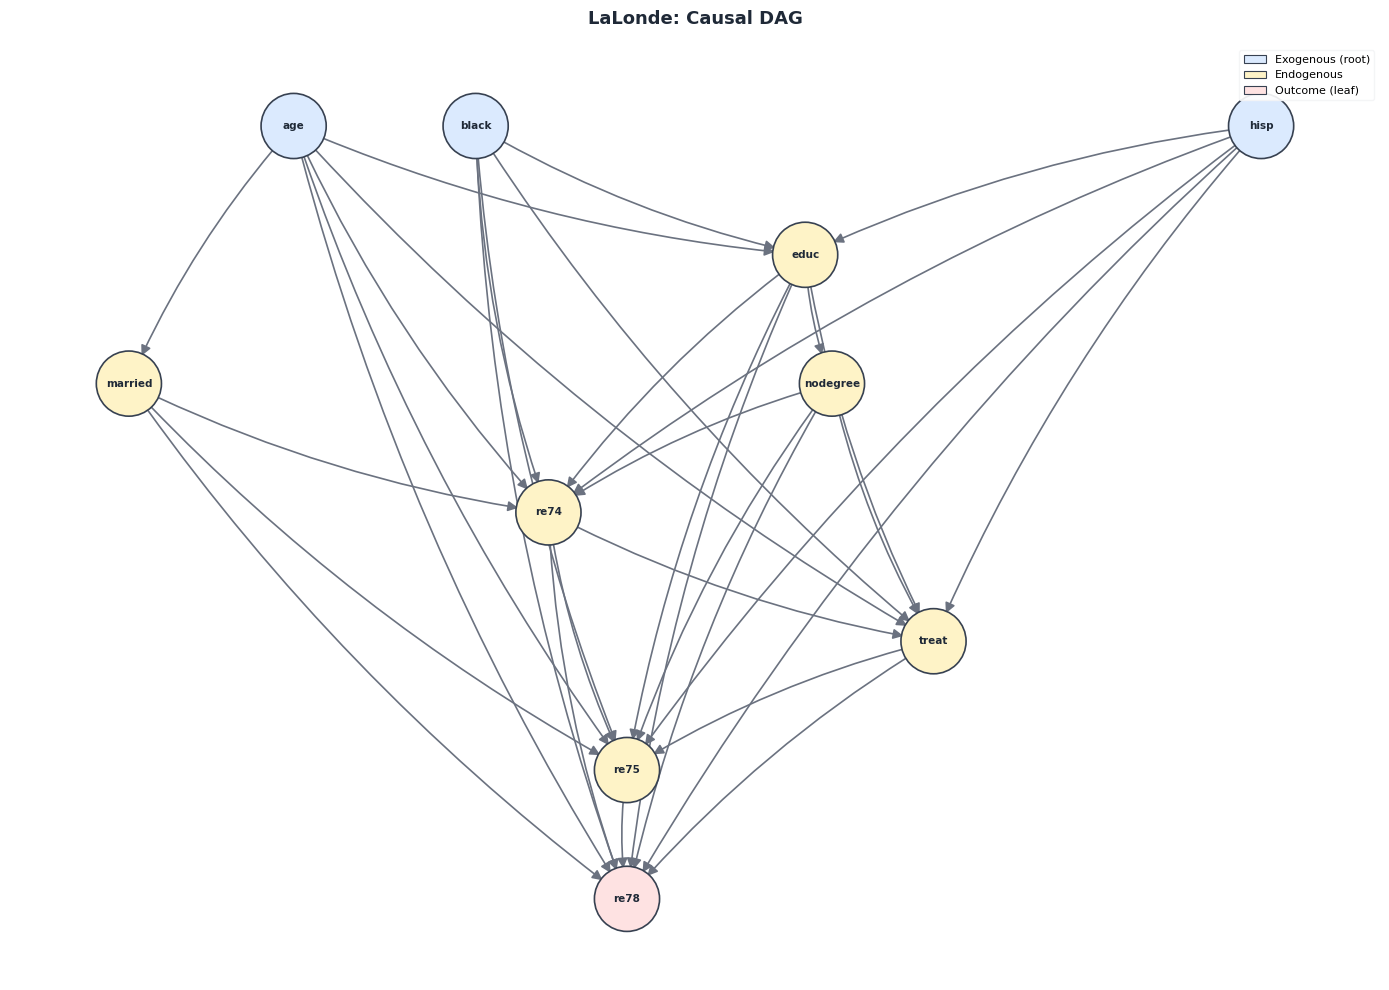

In [11]:
# ## 5. Define the Causal DAG
#
# Pre-treatment variables affect both program participation (selection)
# and post-program earnings (outcomes).

print("=" * 60)
print("Causal Analysis with CausalPype")
print("=" * 60)

dag = {
    'age':         ['educ', 'married', 'treat', 're74', 're75', 're78'],
    'black':       ['educ', 'treat',  're74', 're75', 're78'],
    'hisp':        ['educ', 'treat', 're74', 're75', 're78'],
    'educ':        ['nodegree', 'treat', 're74', 're75', 're78'],
    'nodegree':    ['treat', 're74', 're75', 're78'],
    'married':     [ 're74', 're75', 're78'],
    're74':        ['treat',  're75', 're78'],
    're75':        ['re78'],
    'treat':       ['re75', 're78'],
}

# Used 'better' assignment quality of doWhy. Can also experiment with 'best'.
model = cp.CausalModel(dag, assignment_quality='better')
model.fit(df)

fig, _ = cp.plotting.plot_graph(model, title='LaLonde: Causal DAG')
fig.savefig(FIGDIR / 'dag.pdf')
print("\nDAG saved to figures/lalonde/dag.pdf")




Estimating Average Treatment Effect...
                       ATE Results                        
 Treatment                                           treat
 Outcome                                              re78
 Treatment Value                                         1
 Control Value                                           0
----------------------------------------------------------
 Estimate                                        -835.3004
 Num Samples                                         5,000

  CAUSAL EFFECT (CausalPype): $-835
  EXPERIMENTAL BENCHMARK:     $+1,794
  NAIVE EFFECT:               $-8,498

  Recovery error: $2,629


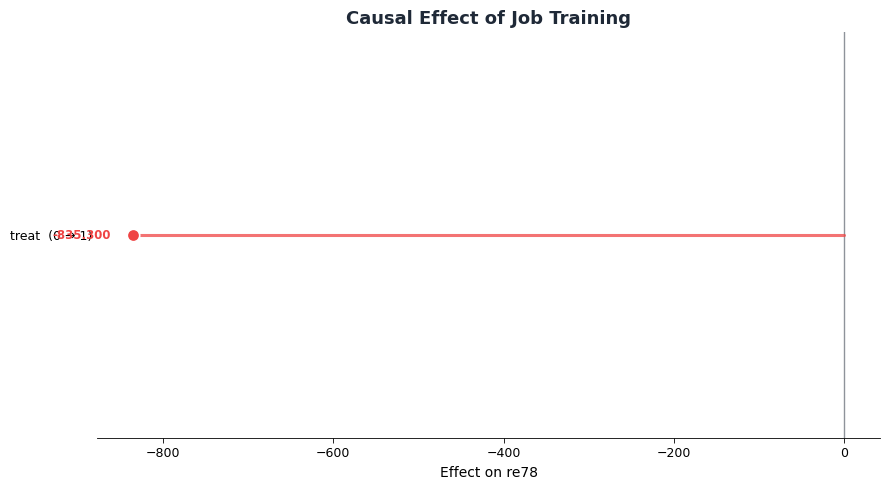

In [12]:
# ## 6. Estimate the Causal Effect
#
# CausalPype adjusts for confounding using the structural causal model.

print("\nEstimating Average Treatment Effect...")

r_ate = model.run(cp.ATE(
    treatment='treat',
    outcome='re78',
    treatment_value=1,
    control_value=0,
    num_samples=5000,
))
print(r_ate)

print(f"\n  CAUSAL EFFECT (CausalPype): ${r_ate.estimate:+,.0f}")
print(f"  EXPERIMENTAL BENCHMARK:     ${EXPERIMENTAL_BENCHMARK:+,.0f}")
print(f"  NAIVE EFFECT:               ${naive_effect:+,.0f}")
print(f"\n  Recovery error: ${abs(r_ate.estimate - EXPERIMENTAL_BENCHMARK):,.0f}")

fig, _ = cp.plotting.plot_effects([r_ate], title='Causal Effect of Job Training')
fig.savefig(FIGDIR / 'ate.pdf')


In [13]:
# ## 7. Validate with Matching
#
# Propensity-style matching

print("\nValidating with nearest-neighbor matching...")

r_knn = model.run(cp.KNNIntervention(
    treatment='treat',
    outcome='re78',
    k=5,
    match_on=['age', 'educ', 'black', 'hisp', 'married', 're74', 're75'],
))
print(r_knn)
print(f"\n  Matching estimate: ${r_knn.estimate:+,.0f}")




Validating with nearest-neighbor matching...
                 KNN Intervention Results                 
 Treatment                                           treat
 Outcome                                              re78
 K                                                       5
 N Treated                                             185
 N Control                                          15,992
----------------------------------------------------------
 ATE                                            -7087.7850
 ATT                                             1882.3260
 ATC                                            -7191.5538
 Std ITE                                         9395.1907
----------------------------------------------------------
 Match Quality (Treated)                            0.3408
 Match Quality (Control)                            2.5579

  Matching estimate: $-7,088



Estimating heterogeneous effects (CATE)...
                       CATE Results                       
 Treatment                                           treat
 Outcome                                              re78
 Effect Modifiers                          age, educ, re75
 Method                                      causal_forest
----------------------------------------------------------
 Mean Effect                                    -2865.3724
 Std Effect                                     10965.9804
 Bounds                          [-68355.8092, 50975.3014]


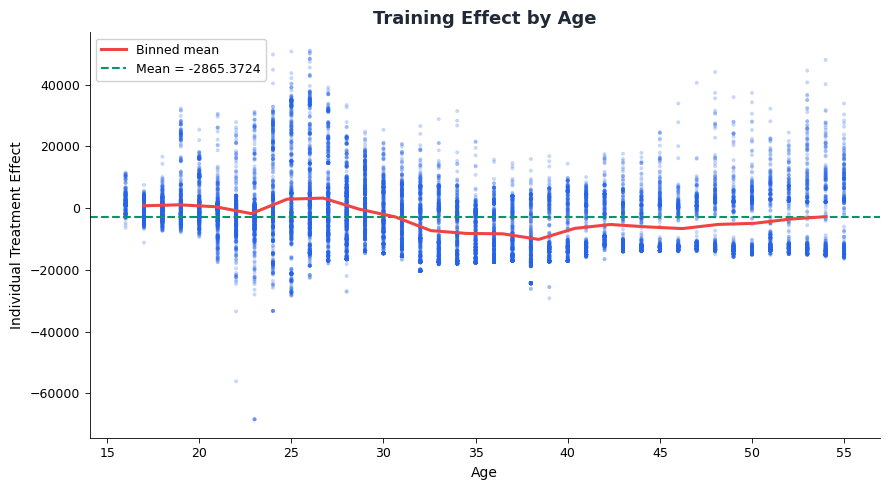

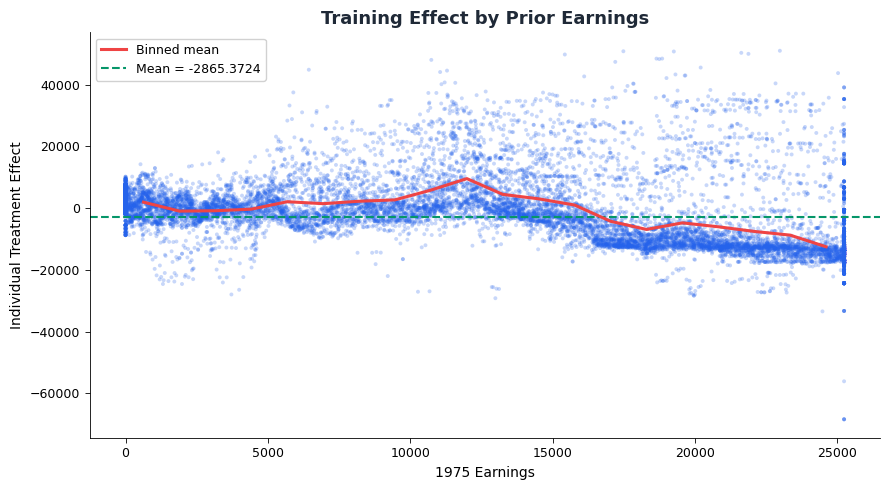

In [14]:
# ## 8. Heterogeneous Treatment Effects
#
# Does the training program help some groups more than others?

print("\nEstimating heterogeneous effects (CATE)...")

r_cate = model.run(cp.CATE(
    treatment='treat',
    outcome='re78',
    effect_modifiers=['age', 'educ', 're75'],
    method='causal_forest',
    n_estimators=200,
    random_state=42,
))
print(r_cate)

fig, _ = cp.plotting.plot_cate_distribution(
    r_cate,
    data=df,
    covariate='age',
    covariate_label='Age',
    title='Training Effect by Age'
)
fig.savefig(FIGDIR / 'cate_by_age.pdf')

fig, _ = cp.plotting.plot_cate_distribution(
    r_cate,
    data=df,
    covariate='re75',
    covariate_label='1975 Earnings',
    title='Training Effect by Prior Earnings'
)
fig.savefig(FIGDIR / 'cate_by_earnings.pdf')



Analyzing drivers of 1978 earnings...


Evaluating set functions...: 100%|██████████| 175/175 [00:25<00:00,  6.99it/s]


                  Arrow Strength Results                  
 Target                                               re78
----------------------------------------------------------
  re75 -> re78                               12378346.7116
  re74 -> re78                                7266713.0113
  age -> re78                                 2108721.4756
  educ -> re78                                1016051.5488
  black -> re78                                610846.0745
  hisp -> re78                                 466202.3347
  nodegree -> re78                             411679.9558
  married -> re78                             -115251.9744
  treat -> re78                                 67519.3010
            Intrinsic Causal Influence Results            
 Target                                               re78
 Total Variance Explained                    74144033.1018
----------------------------------------------------------
  re78 (59.3%)                               43991436.60

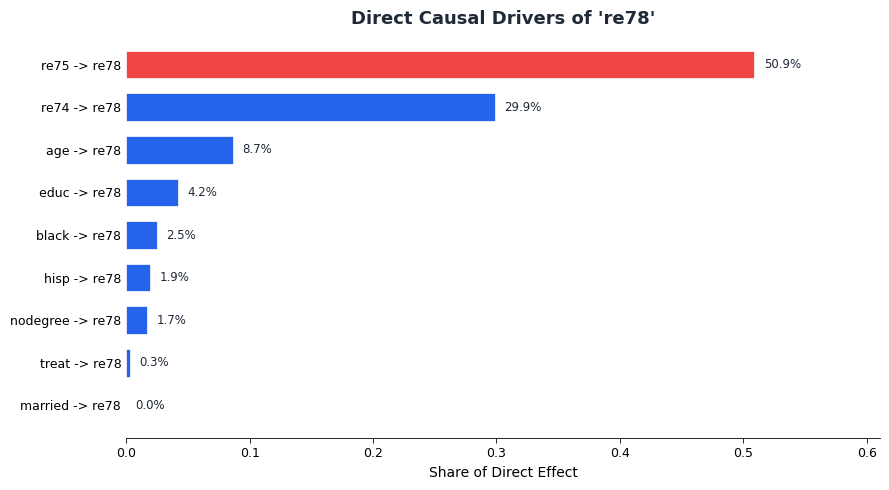

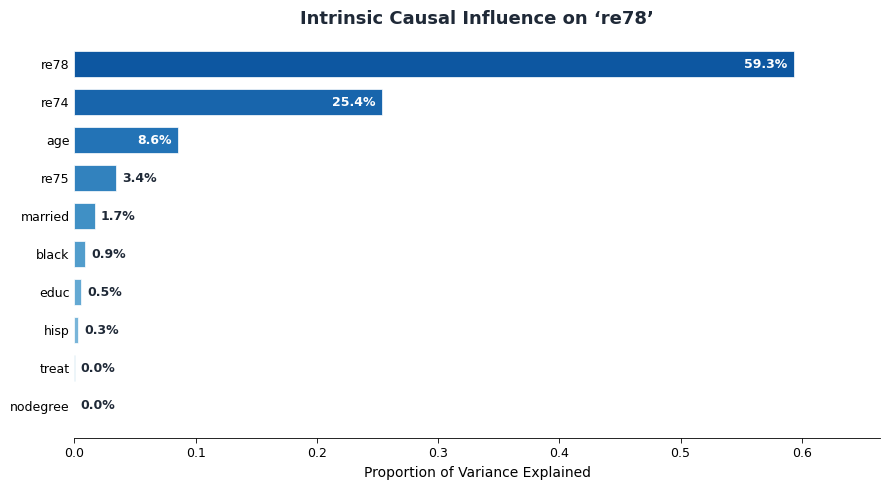

In [15]:
# ## 9. Mechanistic Decomposition
#
# What factors drive post-program earnings?

print("\nAnalyzing drivers of 1978 earnings...")

r_arrow, r_ici = model.run([
    cp.ArrowStrength(target='re78'),
    cp.IntrinsicCausalInfluence(target='re78'),
])
print(r_arrow)
print(r_ici)
fig, _ = cp.plotting.plot_arrow_strength(r_arrow, normalize=True)
fig.savefig(FIGDIR / 'arrow_strength.pdf')
fig, _ = cp.plotting.plot_influences(r_ici)
fig.savefig(FIGDIR / 'influences.pdf')


In [16]:
# ## 10. Counterfactual: Universal Training

print("\nCounterfactual: What if everyone received training?")

r_all_train, r_no_train = model.run([
    cp.Intervention(interventions={'treat': 1}, outcome='re78', num_samples=5000),
    cp.Intervention(interventions={'treat': 0}, outcome='re78', num_samples=5000),
])

print(f"  E[earnings | do(treat=1)]: ${r_all_train.estimate:,.0f}")
print(f"  E[earnings | do(treat=0)]: ${r_no_train.estimate:,.0f}")
print(f"  Population effect:         ${r_all_train.estimate - r_no_train.estimate:+,.0f}")



Counterfactual: What if everyone received training?
  E[earnings | do(treat=1)]: $13,975
  E[earnings | do(treat=0)]: $14,798
  Population effect:         $-823



Sensitivity analysis...


Fitting causal mechanism of node _random_cause: 100%|██████████| 11/11 [00:00<00:00, 12.75it/s]


               Sensitivity Analysis Results               
 Result                                             ROBUST
 Original ATE                                   -1088.1774
----------------------------------------------------------
 Placebo
    Mean Effect                                  -283.0807
    Std Effect                                    407.0021
    P-value                                         0.0000
    Passed                                             Yes
----------------------------------------------------------
 Subset
    Mean Effect                                  -885.9276
    Std Effect                                    320.4665
    Fraction                                        0.8000
    Passed                                             Yes
----------------------------------------------------------
 Random Common Cause
    Mean Effect                                 -1239.9596
    Std Effect                                    311.7333
    Passed        

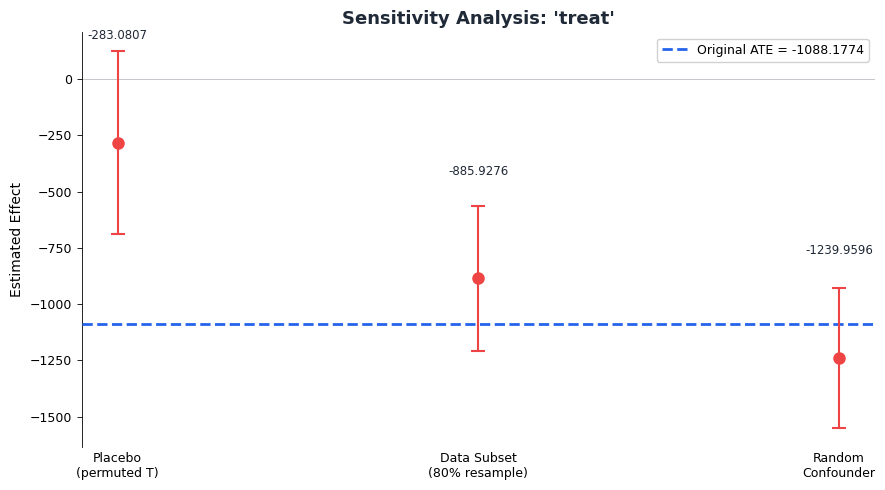

In [17]:
# ## 11. Sensitivity Analysis
#
# How robust is our estimate to model misspecification?

print("\nSensitivity analysis...")

r_sens = model.run(cp.SensitivityAnalysis(
    treatment='treat',
    outcome='re78',
    methods=['placebo', 'subset', 'random_common_cause'],
    num_simulations=5,
    num_samples=2000,
))
print(r_sens)

fig, _ = cp.plotting.plot_sensitivity(r_sens)
fig.savefig(FIGDIR / 'sensitivity.pdf')


In [18]:
# ## 12. Summary

print("\n" + "=" * 60)
print("SUMMARY: LaLonde Real Data Analysis")
print("=" * 60)
print(f"""
Analysis using LaLonde data (NSW + CPS):

1. THE DATA:
   - 185 NSW participants (extremely disadvantaged workers)
   - 15,992 CPS controls (general population)

2. DIRECT CALCULATION OF ATE:
   - Mean 1975 earnings (treated):  ${treated['re75'].mean():,.0f}
   - Mean 1975 earnings (control):  ${control['re75'].mean():,.0f}
   - Estimated effect (erroneous): ${naive_effect:+,.0f}

3. CAUSAL RECOVERY:
   - Experimental benchmark: +${EXPERIMENTAL_BENCHMARK:,}
   - CausalPype estimate:    ${r_ate.estimate:+,.0f}
""")

print("All figures saved to figures/lalonde/")



SUMMARY: LaLonde Real Data Analysis

Analysis using LaLonde data (NSW + CPS):

1. THE DATA:
   - 185 NSW participants (extremely disadvantaged workers)
   - 15,992 CPS controls (general population)

2. DIRECT CALCULATION OF ATE:
   - Mean 1975 earnings (treated):  $1,532
   - Mean 1975 earnings (control):  $13,651
   - Estimated effect (erroneous): $-8,498

3. CAUSAL RECOVERY:
   - Experimental benchmark: +$1,794
   - CausalPype estimate:    $-835

All figures saved to figures/lalonde/


In [19]:
# ## Bonus: Compare with NSW experimental controls
#
# If we had the NSW control group, we could verify the experimental estimate.

print("\n" + "-" * 60)
print("NSW experimental controls to verify benchmark")
print("-" * 60)

nsw_control_path = DATADIR / 'nsw_control.txt'
if not nsw_control_path.exists():
    print("Downloading NSW control data...")
    urllib.request.urlretrieve(
        'https://users.nber.org/~rdehejia/data/nswre74_control.txt',
        nsw_control_path
    )

df_nsw_control = pd.read_csv(nsw_control_path, sep=r'\s+', header=None, names=columns)

experimental_effect = df_treated['re78'].mean() - df_nsw_control['re78'].mean()
print(f"\nExperimental estimate (NSW treated vs NSW control):")
print(f"  Mean earnings (treated): ${df_treated['re78'].mean():,.0f}")
print(f"  Mean earnings (control): ${df_nsw_control['re78'].mean():,.0f}")
print(f"  EXPERIMENTAL EFFECT: ${experimental_effect:+,.0f}")



------------------------------------------------------------
NSW experimental controls to verify benchmark
------------------------------------------------------------

Experimental estimate (NSW treated vs NSW control):
  Mean earnings (treated): $6,349
  Mean earnings (control): $4,555
  EXPERIMENTAL EFFECT: $+1,794
